# Evaluation of object rescaling  experiment

#### Import packages

In [1]:
from pathlib import Path
import re
import math
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams.update({
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], 
})


#### Configuration

In [2]:
EXPERIMENT_ROOT = Path("/data/local/rgaisina/experiments_final/inpainting_rescale_size_for_prediction")
META_DIR = EXPERIMENT_ROOT / "meta"
ANALYSIS_DIR = EXPERIMENT_ROOT / "eval_results_1"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_TAGS = {
    "ResNet-18": "resnet18_a1_in1k",
    "ResNet-50": "resnet50_a1_in1k",
    "ViT-Tiny": "vit_tiny_patch16_224_augreg_in21k_ft_in1k",
    "ViT-Base": "vit_base_patch16_224_augreg_in21k_ft_in1k",
}

TOPK = 5

print("Experiment root:", EXPERIMENT_ROOT)
print("Meta dir:", META_DIR)
print("Analysis dir:", ANALYSIS_DIR)

Experiment root: /data/local/rgaisina/experiments_final/inpainting_rescale_size_for_prediction
Meta dir: /data/local/rgaisina/experiments_final/inpainting_rescale_size_for_prediction/meta
Analysis dir: /data/local/rgaisina/experiments_final/inpainting_rescale_size_for_prediction/eval_results_1


#### Helper functions

In [3]:
def safe_tag(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", s)

def existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def find_original_csv(model_tag: str) -> Path:
    p = existing([
        #META_DIR / f"original_predictions_{model_tag}.csv",
        #META_DIR / f"eval_original_{model_tag}.csv",
        META_DIR / f"eval_original_{model_tag}_top5.csv",
    ])
    if p is None:
        raise FileNotFoundError(f"Could not find original CSV for model_tag={model_tag}")
    return p

def find_generated_csv(model_tag: str) -> Path:
    p = existing([
        META_DIR / f"eval_rescale_size_for_prediction_{model_tag}_top5.csv",
        #META_DIR / f"generated_{model_tag}.csv",
        #META_DIR / f"eval_generated_{model_tag}.csv",
    ])
    if p is None:
        raise FileNotFoundError(f"Could not find generated CSV for model_tag={model_tag}")
    return p

def find_compare_csv(model_tag: str) -> Path:
    p = existing([
        META_DIR / f"eval_rescale_size_for_prediction_compare_{model_tag}_top5.csv",
        # ETA_DIR / f"paired_compare_{model_tag}.csv",
        # META_DIR / f"comparison_{model_tag}.csv",
    ])
    if p is None:
        raise FileNotFoundError(f"Could not find compare CSV for model_tag={model_tag}")
    return p

def infer_scale_order(values):
    def score(v):
        if pd.isna(v):
            return 10_000
        s = str(v)
        m = re.search(r"(\d+)", s)
        if m:
            return -int(m.group(1))
        return 10_000
    uniq = list(pd.unique(pd.Series(values).dropna()))
    return sorted(uniq, key=lambda x: (0 if str(x).lower().startswith("scale") else 1, score(x), str(x)))

def annotate_bars(ax, fmt='{:.2f}', fontsize=9, y_offset=0.01):
    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if np.isnan(height):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + y_offset * y_span,
                fmt.format(height),
                ha='center',
                va='bottom',
                fontsize=fontsize,
                clip_on=False,
            )

In [4]:
original_dfs = {}
generated_dfs = {}
compare_dfs = {}

for model_name, model_tag in MODEL_TAGS.items():
    orig_path = find_original_csv(model_tag)
    gen_path = find_generated_csv(model_tag)
    cmp_path = find_compare_csv(model_tag)

    orig = pd.read_csv(orig_path)
    gen = pd.read_csv(gen_path)
    cmp = pd.read_csv(cmp_path)

    orig["model_name"] = model_name
    gen["model_name"] = model_name
    cmp["model_name"] = model_name

    original_dfs[model_name] = orig
    generated_dfs[model_name] = gen
    compare_dfs[model_name] = cmp

    print(f"{model_name}")
    print("  original :", orig_path.name, orig.shape)
    print("  generated:", gen_path.name, gen.shape)
    print("  compare  :", cmp_path.name, cmp.shape)

ResNet-18
  original : eval_original_resnet18_a1_in1k_top5.csv (55, 21)
  generated: eval_rescale_size_for_prediction_resnet18_a1_in1k_top5.csv (220, 21)
  compare  : eval_rescale_size_for_prediction_compare_resnet18_a1_in1k_top5.csv (220, 30)
ResNet-50
  original : eval_original_resnet50_a1_in1k_top5.csv (55, 21)
  generated: eval_rescale_size_for_prediction_resnet50_a1_in1k_top5.csv (220, 21)
  compare  : eval_rescale_size_for_prediction_compare_resnet50_a1_in1k_top5.csv (220, 30)
ViT-Tiny
  original : eval_original_vit_tiny_patch16_224_augreg_in21k_ft_in1k_top5.csv (55, 21)
  generated: eval_rescale_size_for_prediction_vit_tiny_patch16_224_augreg_in21k_ft_in1k_top5.csv (220, 21)
  compare  : eval_rescale_size_for_prediction_compare_vit_tiny_patch16_224_augreg_in21k_ft_in1k_top5.csv (220, 30)
ViT-Base
  original : eval_original_vit_base_patch16_224_augreg_in21k_ft_in1k_top5.csv (55, 21)
  generated: eval_rescale_size_for_prediction_vit_base_patch16_224_augreg_in21k_ft_in1k_top5.csv (

In [5]:
def normalize_original_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename_map = {}
    if "shape_name" in out.columns and "class_name" not in out.columns:
        rename_map["shape_name"] = "class_name"
    if "shape_wnid" in out.columns and "wnid" not in out.columns:
        rename_map["shape_wnid"] = "wnid"
    out = out.rename(columns=rename_map)
    for c in ["correct_in_top1", "correct_in_top5", "prob_correct", "correct_rank"]:
        if c not in out.columns:
            out[c] = np.nan
    if "original_image_id" not in out.columns:
        out["original_image_id"] = out["image_id"]
    return out

def normalize_generated_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename_map = {}
    if "shape_name" in out.columns and "class_name" not in out.columns:
        rename_map["shape_name"] = "class_name"
    if "shape_wnid" in out.columns and "wnid" not in out.columns:
        rename_map["shape_wnid"] = "wnid"
    out = out.rename(columns=rename_map)

    if "scale_tag" not in out.columns:
        if "condition" in out.columns:
            out["scale_tag"] = out["condition"]
        elif "scale_pct" in out.columns:
            out["scale_tag"] = out["scale_pct"].apply(lambda x: f"scale{int(x):03d}" if pd.notna(x) else None)
        else:
            out["scale_tag"] = "generated"

    if "original_image_id" not in out.columns:
        if "image_id" in out.columns:
            out["original_image_id"] = out["image_id"].astype(str).str.replace(r"__.*$", "", regex=True)
        else:
            out["original_image_id"] = np.nan

    for c in ["correct_in_top1", "correct_in_top5", "prob_correct", "correct_rank"]:
        if c not in out.columns:
            out[c] = np.nan

    return out

def normalize_compare_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename_map = {}
    if "shape_name" in out.columns and "class_name" not in out.columns:
        rename_map["shape_name"] = "class_name"
    if "shape_wnid" in out.columns and "wnid" not in out.columns:
        rename_map["shape_wnid"] = "wnid"
    out = out.rename(columns=rename_map)

    if "scale_tag" not in out.columns:
        if "condition" in out.columns:
            out["scale_tag"] = out["condition"]
        elif "scale_pct" in out.columns:
            out["scale_tag"] = out["scale_pct"].apply(lambda x: f"scale{int(x):03d}" if pd.notna(x) else None)

    for c in [
        "delta_prob_correct_vs_original",
        "delta_logit_correct_vs_original",
        "delta_rank_vs_original",
        "pred_changed_vs_original",
        "correct_in_top1_generated",
        "correct_in_top5_generated",
        "prob_correct_generated",
        "correct_rank_generated",
        "correct_in_top1_original",
        "correct_in_top5_original",
        "prob_correct_original",
        "correct_rank_original",
    ]:
        if c not in out.columns:
            out[c] = np.nan

    alt_map = {
        "delta_prob_correct": "delta_prob_correct_vs_original",
        "delta_logit_correct": "delta_logit_correct_vs_original",
        "delta_rank": "delta_rank_vs_original",
    }
    for src, dst in alt_map.items():
        if src in out.columns and out[dst].isna().all():
            out[dst] = out[src]
    return out

for k in list(original_dfs.keys()):
    original_dfs[k] = normalize_original_df(original_dfs[k])
    generated_dfs[k] = normalize_generated_df(generated_dfs[k])
    compare_dfs[k] = normalize_compare_df(compare_dfs[k])

all_scale_tags = []
for df in generated_dfs.values():
    all_scale_tags.extend(df["scale_tag"].dropna().tolist())
SCALE_ORDER = infer_scale_order(all_scale_tags)
print("Detected scale order:", SCALE_ORDER)

Detected scale order: ['scale100', 'scale075', 'scale050', 'scale025']


In [6]:
health_rows = []
for model_name in MODEL_TAGS:
    o = original_dfs[model_name]
    g = generated_dfs[model_name]
    c = compare_dfs[model_name]
    health_rows.append({
        "model": model_name,
        "n_original": len(o),
        "n_generated": len(g),
        "n_compare": len(c),
        "n_classes_original": o["class_name"].nunique() if "class_name" in o.columns else np.nan,
        "n_classes_generated": g["class_name"].nunique() if "class_name" in g.columns else np.nan,
        "scale_tags_generated": ", ".join(sorted(map(str, g["scale_tag"].dropna().unique()))),
    })
health_df = pd.DataFrame(health_rows)
health_df.to_csv(ANALYSIS_DIR / "dataset_health_report.csv", index=False)
health_df

,model,n_original,n_generated,n_compare,n_classes_original,n_classes_generated,scale_tags_generated
0,ResNet-18,55,220,220,11,11,"scale025, scale050, scale075, scale100"
1,ResNet-50,55,220,220,11,11,"scale025, scale050, scale075, scale100"
2,ViT-Tiny,55,220,220,11,11,"scale025, scale050, scale075, scale100"
3,ViT-Base,55,220,220,11,11,"scale025, scale050, scale075, scale100"


In [7]:
def mean01(s):
    return pd.to_numeric(s, errors="coerce").mean()

overall_rows = []
for model_name in MODEL_TAGS:
    orig = original_dfs[model_name]
    gen = generated_dfs[model_name]
    cmp = compare_dfs[model_name]

    orig_top1 = mean01(orig["correct_in_top1"])
    orig_top5 = mean01(orig["correct_in_top5"])
    orig_prob = pd.to_numeric(orig["prob_correct"], errors="coerce").mean()

    by_scale_gen = gen.groupby("scale_tag", dropna=False).agg(
        top1=("correct_in_top1", mean01),
        top5=("correct_in_top5", mean01),
        prob_correct=("prob_correct", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        n=("image_id", "count"),
    ).reset_index()

    if "image_id_generated" in cmp.columns:
        ncol = ("image_id_generated", "count")
    else:
        ncol = ("scale_tag", "size")

    by_scale_cmp = cmp.groupby("scale_tag", dropna=False).agg(
        delta_prob_vs_orig=("delta_prob_correct_vs_original", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        delta_rank_vs_orig=("delta_rank_vs_original", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        pred_changed_rate=("pred_changed_vs_original", mean01),
        top1_gen=("correct_in_top1_generated", mean01),
        top5_gen=("correct_in_top5_generated", mean01),
        prob_gen=("prob_correct_generated", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        top1_orig=("correct_in_top1_original", mean01),
        top5_orig=("correct_in_top5_original", mean01),
        prob_orig=("prob_correct_original", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        n=ncol,
    ).reset_index()

    merged = by_scale_gen.merge(by_scale_cmp, on="scale_tag", how="outer", suffixes=("", "_cmp"))
    merged["model"] = model_name
    merged["orig_top1_global"] = orig_top1
    merged["orig_top5_global"] = orig_top5
    merged["orig_prob_global"] = orig_prob
    overall_rows.append(merged)

overall_by_model_scale = pd.concat(overall_rows, ignore_index=True)
overall_by_model_scale["scale_tag"] = pd.Categorical(overall_by_model_scale["scale_tag"], categories=SCALE_ORDER, ordered=True)
overall_by_model_scale = overall_by_model_scale.sort_values(["model", "scale_tag"]).reset_index(drop=True)
overall_by_model_scale.to_csv(ANALYSIS_DIR / "overall_by_model_scale.csv", index=False)
overall_by_model_scale.head(12)

,scale_tag,top1,top5,prob_correct,n,delta_prob_vs_orig,delta_rank_vs_orig,pred_changed_rate,top1_gen,top5_gen,prob_gen,top1_orig,top5_orig,prob_orig,n_cmp,model,orig_top1_global,orig_top5_global,orig_prob_global
0,scale100,0.890909,1.000000,0.829706,55,-0.055124,0.163636,0.109091,0.890909,1.000000,0.829706,1.0,1.0,0.884830,55,ResNet-18,1.0,1.0,0.884830
1,scale075,0.836364,1.000000,0.719917,55,-0.164913,0.200000,0.163636,0.836364,1.000000,0.719917,1.0,1.0,0.884830,55,ResNet-18,1.0,1.0,0.884830
2,scale050,0.509091,0.890909,0.408390,55,-0.476440,1.200000,0.490909,0.509091,0.890909,0.408390,1.0,1.0,0.884830,55,ResNet-18,1.0,1.0,0.884830
3,scale025,0.090909,0.272727,0.055321,55,-0.829509,4.036364,0.909091,0.090909,0.272727,0.055321,1.0,1.0,0.884830,55,ResNet-18,1.0,1.0,0.884830
4,scale100,0.927273,1.000000,0.893621,55,-0.053603,0.090909,0.072727,0.927273,1.000000,0.893621,1.0,1.0,0.947225,55,ResNet-50,1.0,1.0,0.947225
5,scale075,0.927273,1.000000,0.861850,55,-0.085375,0.090909,0.072727,0.927273,1.000000,0.861850,1.0,1.0,0.947225,55,ResNet-50,1.0,1.0,0.947225
6,scale050,0.763636,0.981818,0.660144,55,-0.287080,0.436364,0.236364,0.763636,0.981818,0.660144,1.0,1.0,0.947225,55,ResNet-50,1.0,1.0,0.947225
7,scale025,0.163636,0.490909,0.135010,55,-0.812214,3.472727,0.836364,0.163636,0.490909,0.135010,1.0,1.0,0.947225,55,ResNet-50,1.0,1.0,0.947225
8,scale100,0.981818,1.000000,0.843823,55,-0.050902,0.018182,0.018182,0.981818,1.000000,0.843823,1.0,1.0,0.894725,55,ViT-Base,1.0,1.0,0.894725
9,scale075,0.909091,1.000000,0.800747,55,-0.093977,0.145455,0.090909,0.909091,1.000000,0.800747,1.0,1.0,0.894725,55,ViT-Base,1.0,1.0,0.894725


In [8]:
baseline_rows = []
for model_name in MODEL_TAGS:
    orig = original_dfs[model_name]
    gen = generated_dfs[model_name]
    cmp = compare_dfs[model_name]

    orig_top1 = mean01(orig["correct_in_top1"])
    orig_top5 = mean01(orig["correct_in_top5"])
    orig_prob = pd.to_numeric(orig["prob_correct"], errors="coerce").mean()

    if "scale100" in set(gen["scale_tag"].dropna().astype(str)):
        baseline_tag = "scale100"
    else:
        tags = infer_scale_order(gen["scale_tag"].dropna().astype(str).tolist())
        baseline_tag = tags[0] if len(tags) else None

    g0 = gen[gen["scale_tag"].astype(str) == str(baseline_tag)].copy()
    c0 = cmp[cmp["scale_tag"].astype(str) == str(baseline_tag)].copy()

    baseline_rows.append({
        "model": model_name,
        "baseline_tag": baseline_tag,
        "original_top1": orig_top1,
        "pipeline_top1": mean01(g0["correct_in_top1"]),
        "delta_top1_pipeline_minus_original": mean01(g0["correct_in_top1"]) - orig_top1 if len(g0) else np.nan,
        "original_top5": orig_top5,
        "pipeline_top5": mean01(g0["correct_in_top5"]),
        "delta_top5_pipeline_minus_original": mean01(g0["correct_in_top5"]) - orig_top5 if len(g0) else np.nan,
        "original_prob_correct": orig_prob,
        "pipeline_prob_correct": pd.to_numeric(g0["prob_correct"], errors="coerce").mean(),
        "delta_prob_pipeline_minus_original": pd.to_numeric(g0["prob_correct"], errors="coerce").mean() - orig_prob if len(g0) else np.nan,
        "pred_changed_rate_vs_original": mean01(c0["pred_changed_vs_original"]),
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(ANALYSIS_DIR / "original_vs_pipeline_baseline.csv", index=False)
baseline_df

,model,baseline_tag,original_top1,pipeline_top1,delta_top1_pipeline_minus_original,original_top5,pipeline_top5,delta_top5_pipeline_minus_original,original_prob_correct,pipeline_prob_correct,delta_prob_pipeline_minus_original,pred_changed_rate_vs_original
0,ResNet-18,scale100,1.0,0.890909,-0.109091,1.0,1.0,0.0,0.884830,0.829706,-0.055124,0.109091
1,ResNet-50,scale100,1.0,0.927273,-0.072727,1.0,1.0,0.0,0.947225,0.893621,-0.053603,0.072727
2,ViT-Tiny,scale100,1.0,0.927273,-0.072727,1.0,1.0,0.0,0.854166,0.788128,-0.066038,0.072727
3,ViT-Base,scale100,1.0,0.981818,-0.018182,1.0,1.0,0.0,0.894725,0.843823,-0.050902,0.018182


In [9]:
class_rows = []
for model_name in MODEL_TAGS:
    gen = generated_dfs[model_name]
    cmp = compare_dfs[model_name]

    g = gen.groupby(["class_name", "scale_tag"], dropna=False).agg(
        top1=("correct_in_top1", mean01),
        top5=("correct_in_top5", mean01),
        prob_correct=("prob_correct", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        n=("image_id", "count"),
    ).reset_index()

    c = cmp.groupby(["class_name", "scale_tag"], dropna=False).agg(
        delta_prob_vs_orig=("delta_prob_correct_vs_original", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        pred_changed_rate=("pred_changed_vs_original", mean01),
        top1_gen=("correct_in_top1_generated", mean01),
        top1_orig=("correct_in_top1_original", mean01),
    ).reset_index()

    m = g.merge(c, on=["class_name", "scale_tag"], how="outer")
    m["model"] = model_name
    class_rows.append(m)

class_by_model_scale = pd.concat(class_rows, ignore_index=True)
class_by_model_scale["scale_tag"] = pd.Categorical(class_by_model_scale["scale_tag"], categories=SCALE_ORDER, ordered=True)
class_by_model_scale = class_by_model_scale.sort_values(["model", "class_name", "scale_tag"]).reset_index(drop=True)
class_by_model_scale.to_csv(ANALYSIS_DIR / "class_by_model_scale.csv", index=False)
class_by_model_scale.head()

,class_name,scale_tag,top1,top5,prob_correct,n,delta_prob_vs_orig,pred_changed_rate,top1_gen,top1_orig,model
0,african_elephant,scale100,1.0,1.0,0.767918,5,-0.016441,0.0,1.0,1.0,ResNet-18
1,african_elephant,scale075,0.8,1.0,0.633964,5,-0.150395,0.2,0.8,1.0,ResNet-18
2,african_elephant,scale050,0.4,0.8,0.357414,5,-0.426945,0.6,0.4,1.0,ResNet-18
3,african_elephant,scale025,0.2,0.2,0.057977,5,-0.726382,0.8,0.2,1.0,ResNet-18
4,airliner,scale100,1.0,1.0,0.989077,5,-0.001147,0.0,1.0,1.0,ResNet-18


In [10]:
table_top1 = []
table_top5 = []
table_prob = []

for model_name in MODEL_TAGS:
    orig = original_dfs[model_name]
    gen = generated_dfs[model_name]

    row_top1 = {"model": model_name, "original": mean01(orig["correct_in_top1"])}
    row_top5 = {"model": model_name, "original": mean01(orig["correct_in_top5"])}
    row_prob = {"model": model_name, "original": pd.to_numeric(orig["prob_correct"], errors="coerce").mean()}

    for scale_tag in SCALE_ORDER:
        sub = gen[gen["scale_tag"].astype(str) == str(scale_tag)]
        row_top1[str(scale_tag)] = mean01(sub["correct_in_top1"])
        row_top5[str(scale_tag)] = mean01(sub["correct_in_top5"])
        row_prob[str(scale_tag)] = pd.to_numeric(sub["prob_correct"], errors="coerce").mean()

    table_top1.append(row_top1)
    table_top5.append(row_top5)
    table_prob.append(row_prob)

table_top1 = pd.DataFrame(table_top1)
table_top5 = pd.DataFrame(table_top5)
table_prob = pd.DataFrame(table_prob)

table_top1.to_csv(ANALYSIS_DIR / "table_top1_original_and_scales.csv", index=False)
table_top5.to_csv(ANALYSIS_DIR / "table_top5_original_and_scales.csv", index=False)
table_prob.to_csv(ANALYSIS_DIR / "table_prob_original_and_scales.csv", index=False)

display(table_top1)
display(table_top5)

,model,original,scale100,scale075,scale050,scale025
0,ResNet-18,1.0,0.890909,0.836364,0.509091,0.090909
1,ResNet-50,1.0,0.927273,0.927273,0.763636,0.163636
2,ViT-Tiny,1.0,0.927273,0.818182,0.618182,0.163636
3,ViT-Base,1.0,0.981818,0.909091,0.836364,0.327273


,model,original,scale100,scale075,scale050,scale025
0,ResNet-18,1.0,1.0,1.000000,0.890909,0.272727
1,ResNet-50,1.0,1.0,1.000000,0.981818,0.490909
2,ViT-Tiny,1.0,1.0,0.963636,0.890909,0.418182
3,ViT-Base,1.0,1.0,1.000000,1.000000,0.581818


In [11]:
def savefig(name: str):
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / name, bbox_inches="tight")
    plt.show()

#### Comparison to original

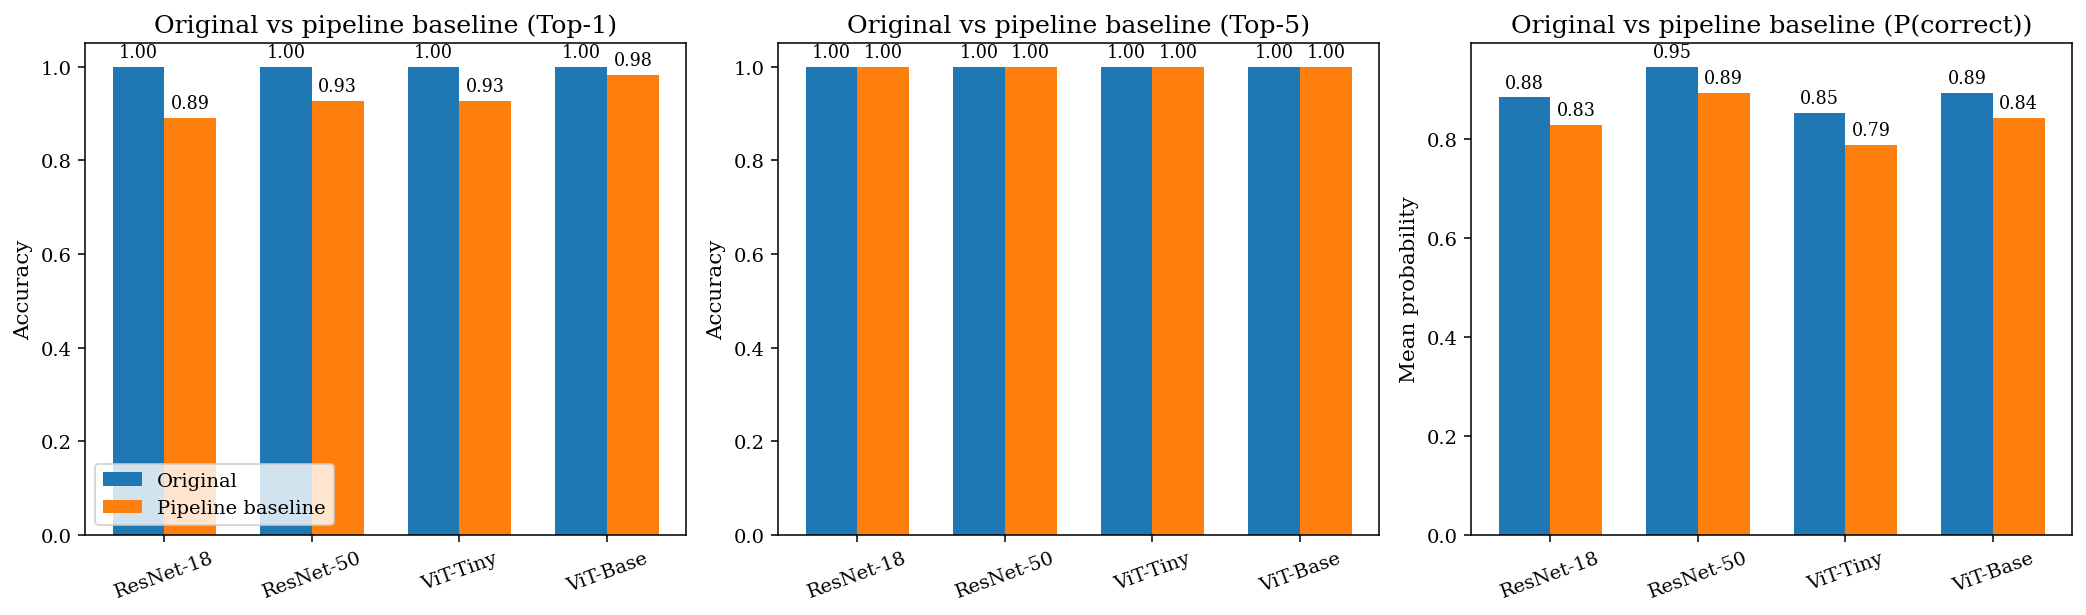

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x = np.arange(len(baseline_df))
w = 0.35

axes[0].bar(x - w/2, baseline_df["original_top1"], width=w, label="Original")
axes[0].bar(x + w/2, baseline_df["pipeline_top1"], width=w, label="Pipeline baseline")
axes[0].set_xticks(x)
axes[0].set_xticklabels(baseline_df["model"], rotation=20)
axes[0].set_title("Original vs pipeline baseline (Top-1)")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

annotate_bars(axes[0], fmt='{:.2f}', fontsize=9, y_offset=0.012)

axes[1].bar(x - w/2, baseline_df["original_top5"], width=w, label="Original")
axes[1].bar(x + w/2, baseline_df["pipeline_top5"], width=w, label="Pipeline baseline")
axes[1].set_xticks(x)
axes[1].set_xticklabels(baseline_df["model"], rotation=20)
axes[1].set_title("Original vs pipeline baseline (Top-5)")
axes[1].set_ylabel("Accuracy")

annotate_bars(axes[1], fmt='{:.2f}', fontsize=9, y_offset=0.012)

axes[2].bar(x - w/2, baseline_df["original_prob_correct"], width=w, label="Original")
axes[2].bar(x + w/2, baseline_df["pipeline_prob_correct"], width=w, label="Pipeline baseline")
axes[2].set_xticks(x)
axes[2].set_xticklabels(baseline_df["model"], rotation=20)
axes[2].set_title("Original vs pipeline baseline (P(correct))")
axes[2].set_ylabel("Mean probability")

annotate_bars(axes[2], fmt='{:.2f}', fontsize=9, y_offset=0.012)

savefig("01_original_vs_pipeline_baseline_triptych.png")

#### Top-1 / top-5 decisions

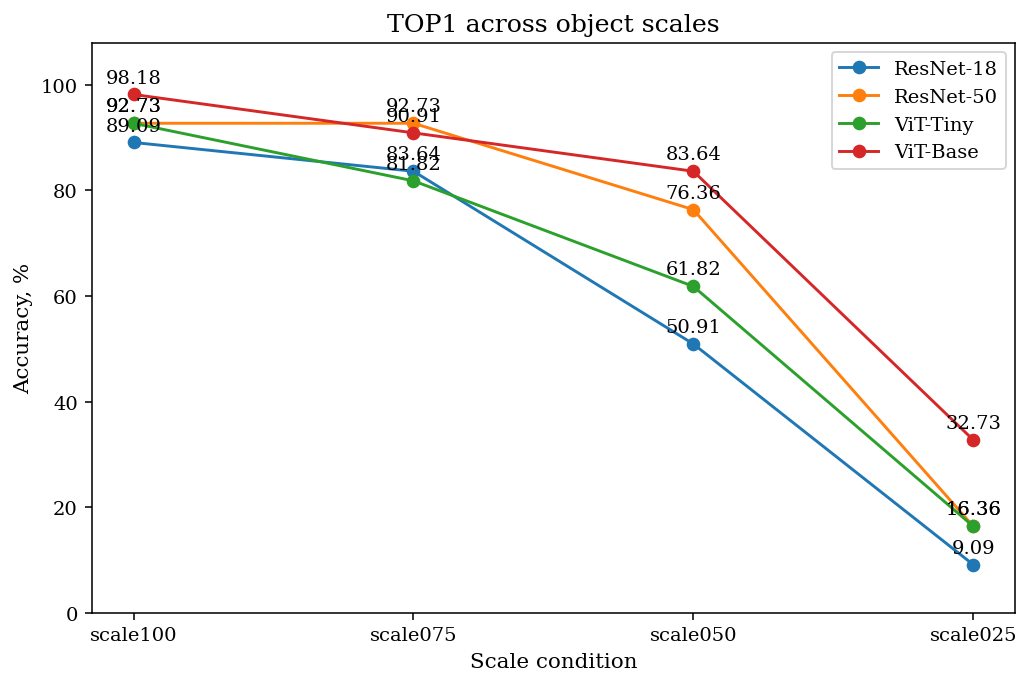

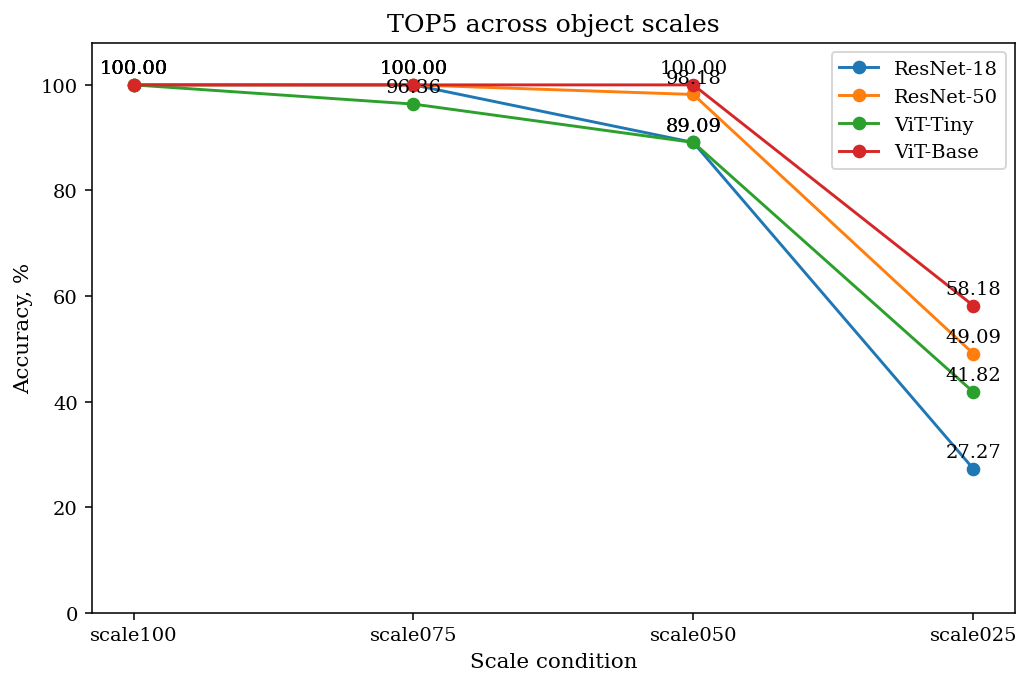

In [13]:
for metric, fname in [("top1", "02_scale_curve_top1.png"), ("top5", "03_scale_curve_top5.png")]:
    plt.figure(figsize=(7.5, 5))
    for model_name in MODEL_TAGS:
        sub = overall_by_model_scale[overall_by_model_scale["model"] == model_name].copy()
        sub = sub.sort_values("scale_tag")
        x = sub["scale_tag"].astype(str)
        y = sub[metric] * 100
        plt.plot(sub["scale_tag"].astype(str), sub[metric] * 100, marker="o", label=model_name)
        for xi, yi in zip(x, y):
            if not np.isnan(yi):
                plt.text(
                    xi,
                    yi + 1.5,   # small vertical offset
                    f"{yi:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=10
                )
    plt.title(f"{metric.upper()} across object scales")
    plt.xlabel("Scale condition")
    plt.ylabel("Accuracy, %")
    plt.ylim(0, 108)
    plt.legend()
    savefig(fname)

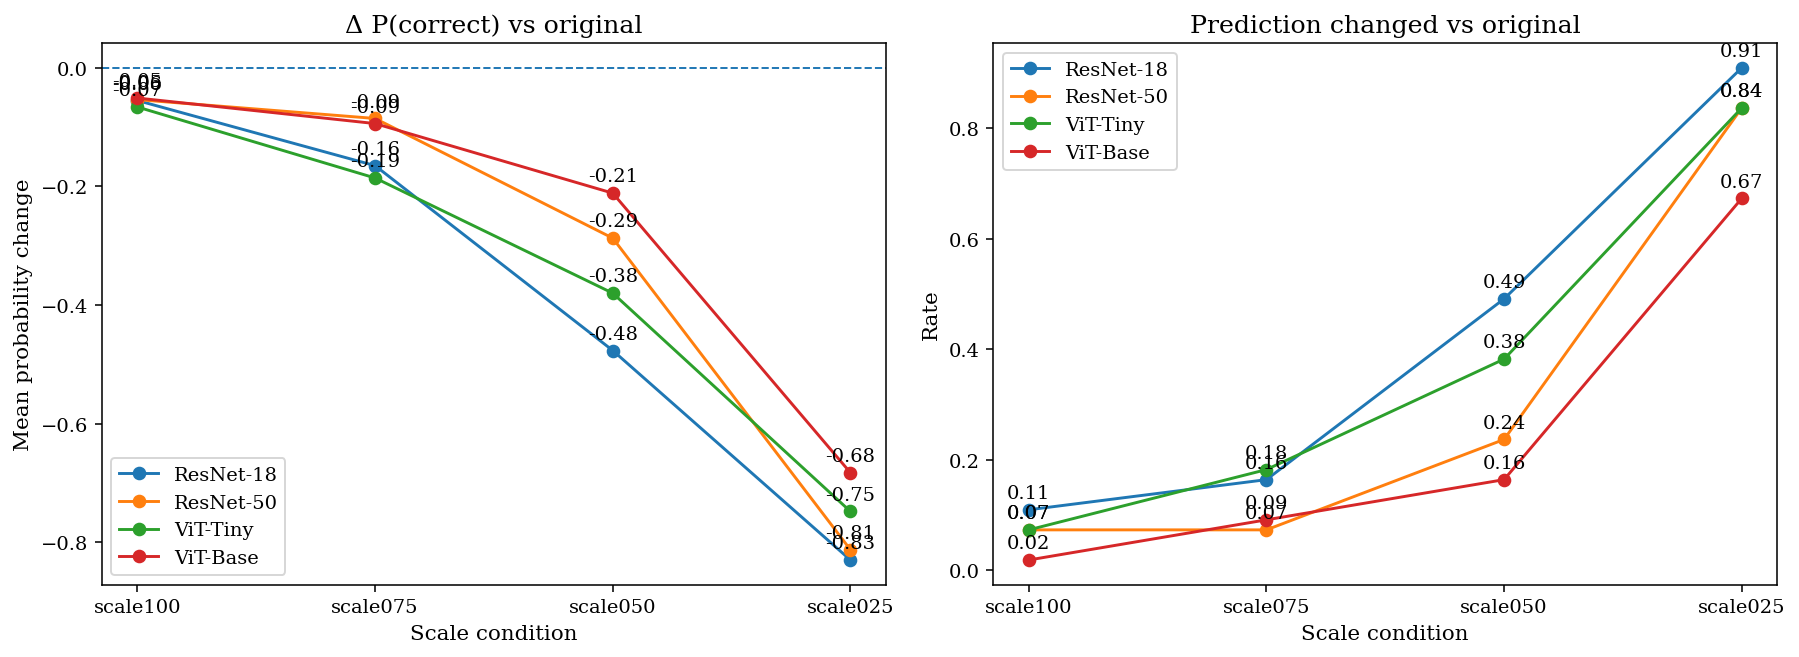

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for model_name in MODEL_TAGS:
    sub = overall_by_model_scale[overall_by_model_scale["model"] == model_name].copy()

    x = sub["scale_tag"].astype(str)

    y1 = sub["delta_prob_vs_orig"]
    y2 = sub["pred_changed_rate"]

    axes[0].plot(x, y1, marker="o", label=model_name)
    axes[1].plot(x, y2, marker="o", label=model_name)

    # ---- ANNOTATIONS ----
    for xi, yi in zip(x, y1):
        axes[0].annotate(
            f"{yi:.2f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=10
        )

    for xi, yi in zip(x, y2):
        axes[1].annotate(
            f"{yi:.2f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=10
        )
axes[0].axhline(0, linestyle="--", linewidth=1)

axes[0].set_title("Δ P(correct) vs original")
axes[0].set_xlabel("Scale condition")
axes[0].set_ylabel("Mean probability change")

axes[1].set_title("Prediction changed vs original")
axes[1].set_xlabel("Scale condition")
axes[1].set_ylabel("Rate")

axes[0].legend()
axes[1].legend()
savefig("04_end_to_end_degradation_vs_original.png")

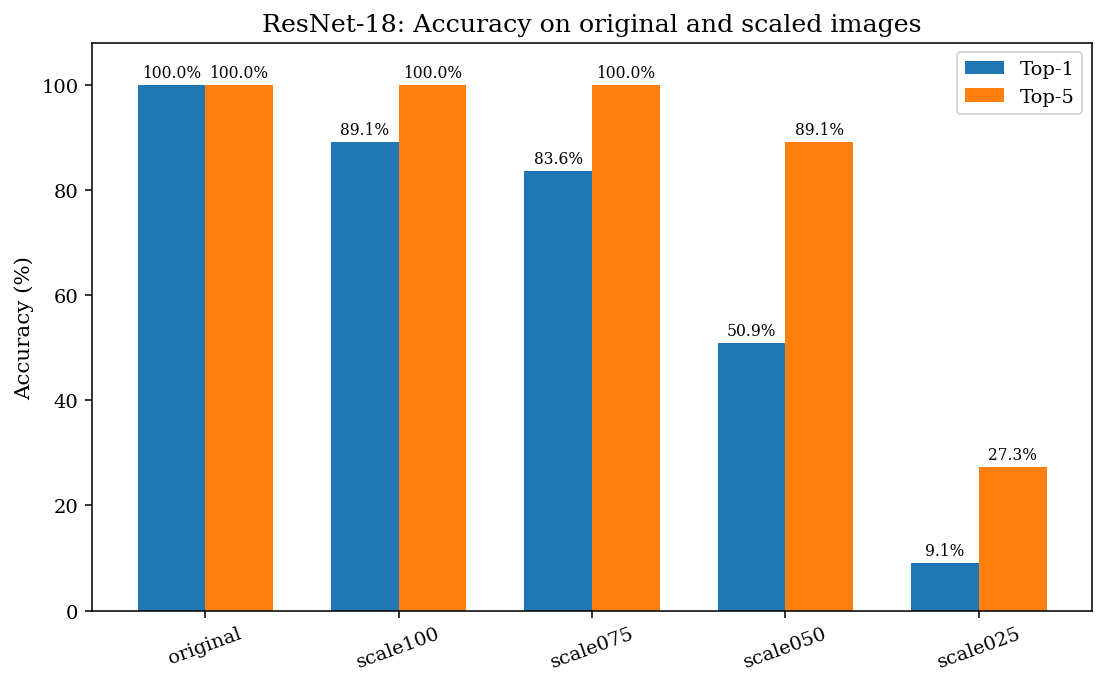

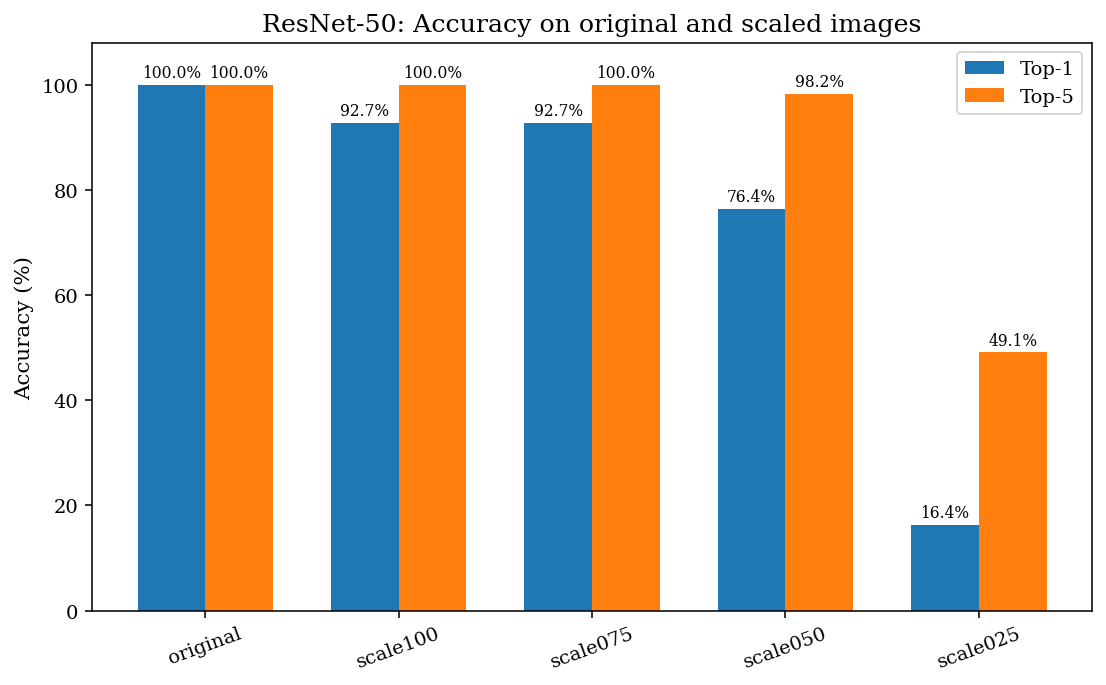

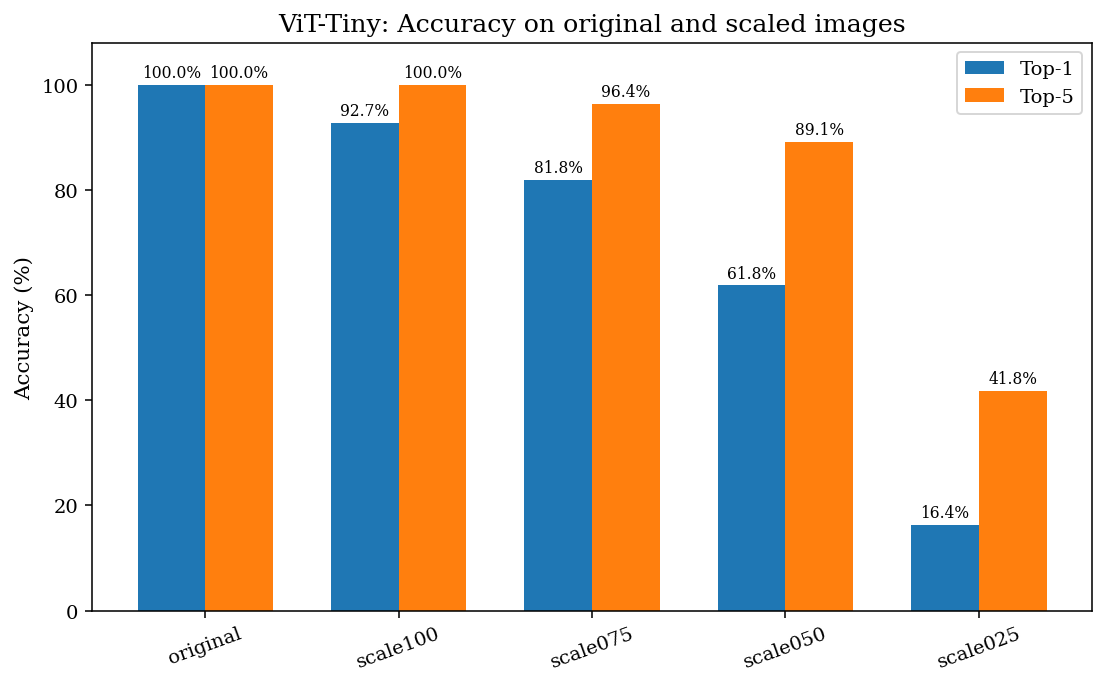

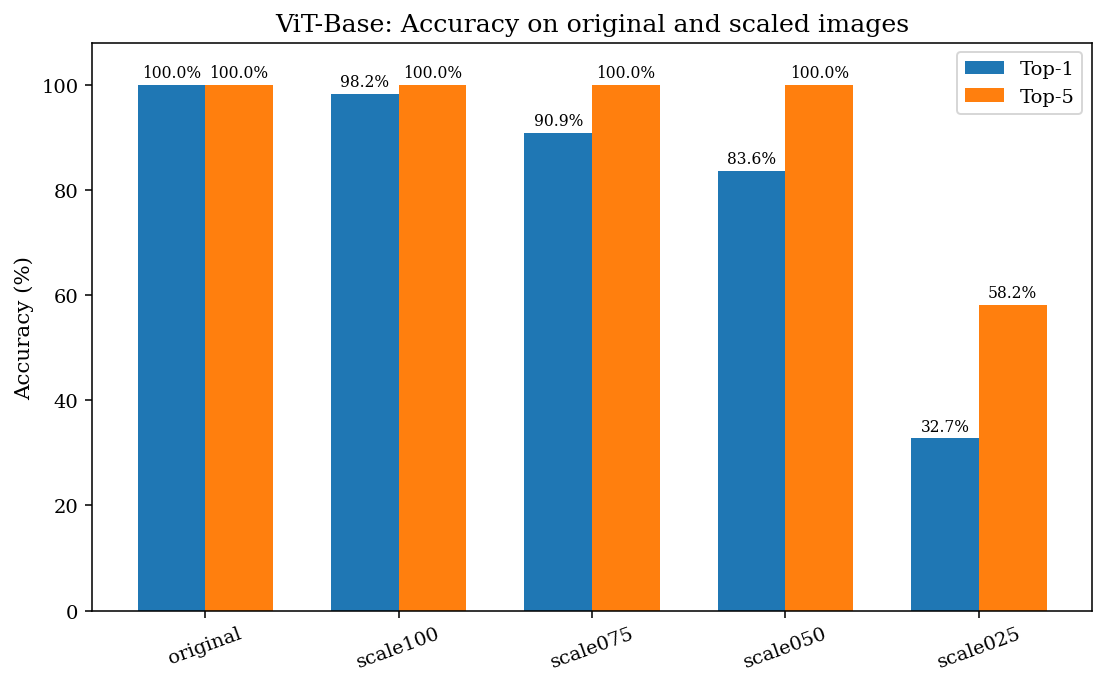

In [15]:
for model_name in MODEL_TAGS:
    orig = original_dfs[model_name]
    gen = generated_dfs[model_name]

    labels = ["original"] + [str(s) for s in SCALE_ORDER]
    top1_vals = [mean01(orig["correct_in_top1"])]
    top5_vals = [mean01(orig["correct_in_top5"])]

    for s in SCALE_ORDER:
        sub = gen[gen["scale_tag"].astype(str) == str(s)]
        top1_vals.append(mean01(sub["correct_in_top1"]))
        top5_vals.append(mean01(sub["correct_in_top5"]))
        top1_vals_pct = [v * 100 for v in top1_vals]
        top5_vals_pct = [v * 100 for v in top5_vals]

    x = np.arange(len(labels))
    w = 0.35
    plt.figure(figsize=(8, 5))
    bars1 = plt.bar(x - w/2, top1_vals_pct, width=w, label="Top-1")
    bars2 = plt.bar(x + w/2, top5_vals_pct, width=w, label="Top-5")
    plt.bar_label(bars1, labels=[f"{v:.1f}%" for v in top1_vals_pct], padding=2, fontsize=8)
    plt.bar_label(bars2, labels=[f"{v:.1f}%" for v in top5_vals_pct], padding=2, fontsize=8)
    plt.xticks(x, labels, rotation=20)
    plt.ylim(0, 108)
    plt.ylabel("Accuracy (%)")
    plt.title(f"{model_name}: Accuracy on original and scaled images")
    plt.legend()
    
    savefig(f"05_{safe_tag(model_name)}_original_and_scales_bar.png")

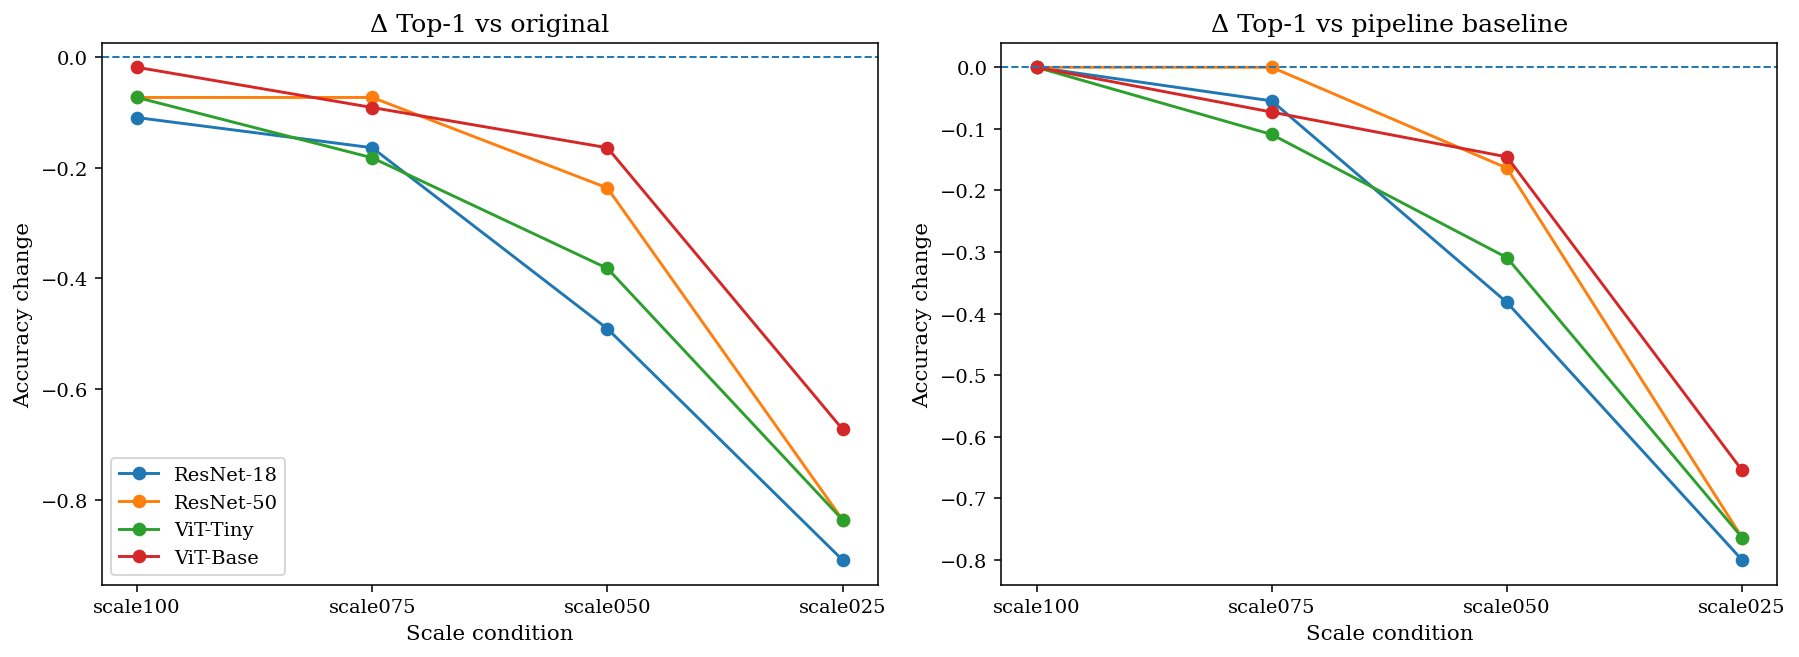

In [16]:
rows = []
for model_name in MODEL_TAGS:
    gen = generated_dfs[model_name]
    orig = original_dfs[model_name]

    base_tag = "scale100" if "scale100" in set(gen["scale_tag"].astype(str)) else SCALE_ORDER[0]
    orig_top1 = mean01(orig["correct_in_top1"])
    g_base = gen[gen["scale_tag"].astype(str) == str(base_tag)]
    base_top1 = mean01(g_base["correct_in_top1"])
    base_prob = pd.to_numeric(g_base["prob_correct"], errors="coerce").mean()

    for s in SCALE_ORDER:
        gs = gen[gen["scale_tag"].astype(str) == str(s)]
        rows.append({
            "model": model_name,
            "scale_tag": s,
            "delta_top1_vs_original": mean01(gs["correct_in_top1"]) - orig_top1,
            "delta_top1_vs_pipeline_baseline": mean01(gs["correct_in_top1"]) - base_top1,
            "delta_prob_vs_pipeline_baseline": pd.to_numeric(gs["prob_correct"], errors="coerce").mean() - base_prob,
        })

baseline_decomp = pd.DataFrame(rows)
baseline_decomp["scale_tag"] = pd.Categorical(baseline_decomp["scale_tag"], categories=SCALE_ORDER, ordered=True)
baseline_decomp = baseline_decomp.sort_values(["model", "scale_tag"])
baseline_decomp.to_csv(ANALYSIS_DIR / "baseline_decomposition.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for model_name in MODEL_TAGS:
    sub = baseline_decomp[baseline_decomp["model"] == model_name]
    axes[0].plot(sub["scale_tag"].astype(str), sub["delta_top1_vs_original"], marker="o", label=model_name)
    axes[1].plot(sub["scale_tag"].astype(str), sub["delta_top1_vs_pipeline_baseline"], marker="o", label=model_name)

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Δ Top-1 vs original")
axes[1].set_title("Δ Top-1 vs pipeline baseline")
for ax in axes:
    ax.set_xlabel("Scale condition")
    ax.set_ylabel("Accuracy change")
axes[0].legend()
savefig("06_baseline_decomposition_top1.png")

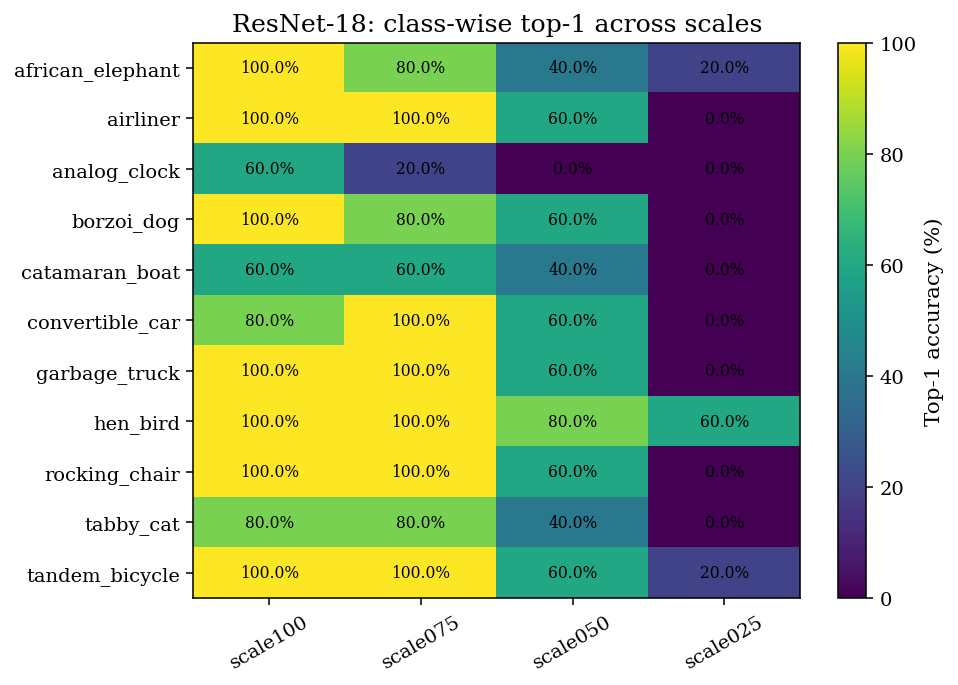

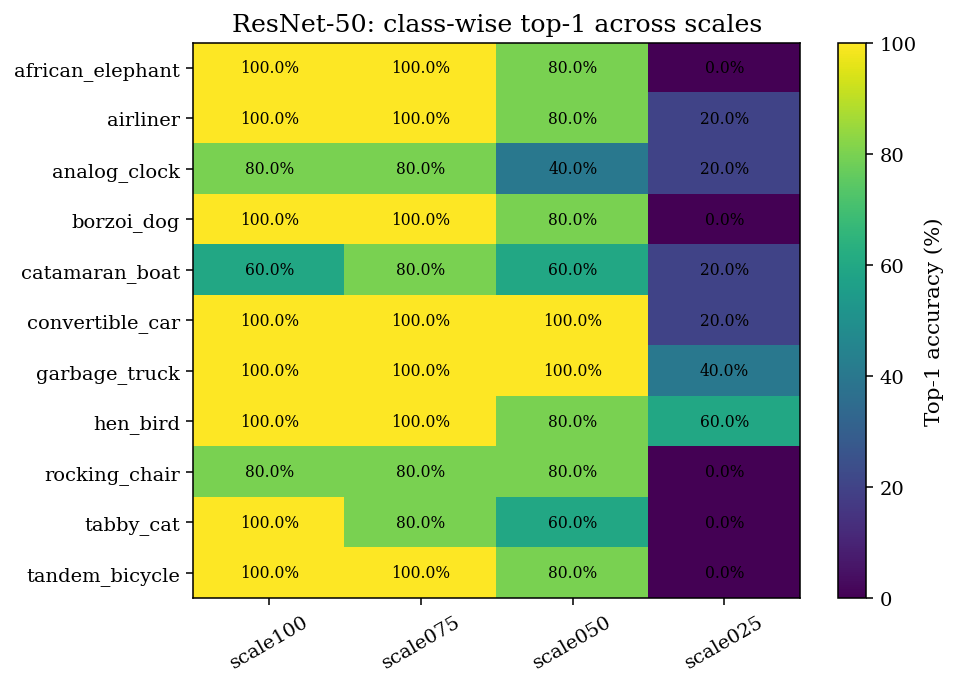

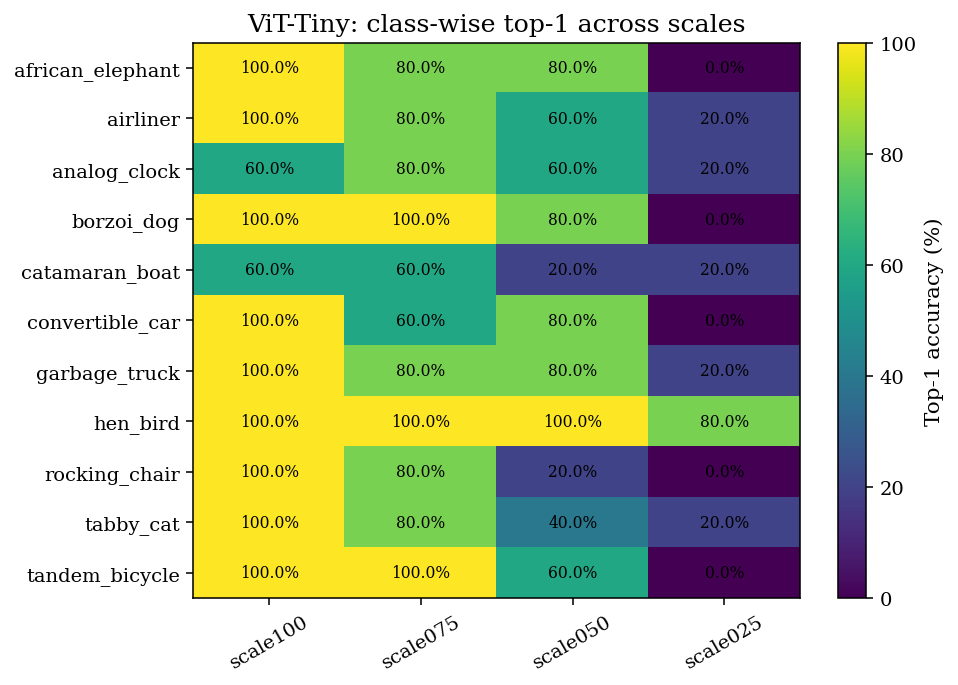

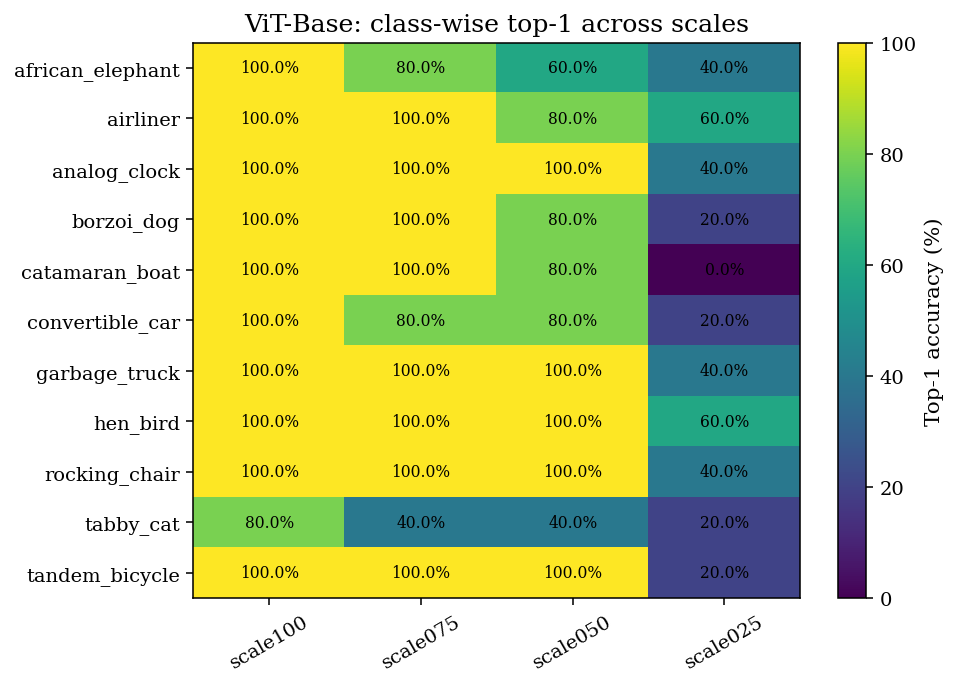

In [17]:
for model_name in MODEL_TAGS:
    sub = class_by_model_scale[class_by_model_scale["model"] == model_name].copy()
    piv = (
        sub.pivot(index="class_name", columns="scale_tag", values="top1")
        .reindex(columns=SCALE_ORDER)
    )

    piv_pct = piv * 100

    plt.figure(figsize=(7, max(5, 0.35 * len(piv_pct))))
    im = plt.imshow(piv_pct.fillna(np.nan), aspect="auto", vmin=0, vmax=100)
    plt.colorbar(im, label="Top-1 accuracy (%)")
    plt.xticks(np.arange(len(piv_pct.columns)), piv_pct.columns, rotation=30)
    plt.yticks(np.arange(len(piv_pct.index)), piv_pct.index)
    plt.title(f"{model_name}: class-wise top-1 across scales")

    for i in range(len(piv_pct.index)):
        for j in range(len(piv_pct.columns)):
            val = piv_pct.iloc[i, j]
            label = "" if pd.isna(val) else f"{val:.1f}%"
            plt.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    plt.tight_layout()
    savefig(f"07_heatmap_top1_{safe_tag(model_name)}.png")

In [19]:
smallest_scale = str(SCALE_ORDER[-1]) if len(SCALE_ORDER) else None
best_worst_rows = []

for model_name in MODEL_TAGS:
    sub = class_by_model_scale[
        (class_by_model_scale["model"] == model_name) &
        (class_by_model_scale["scale_tag"].astype(str) == smallest_scale)
    ].copy()

    if len(sub) == 0:
        continue

    best = sub.sort_values("top1", ascending=False).head(5).copy()
    best["group"] = "best"
    worst = sub.sort_values("top1", ascending=True).head(5).copy()
    worst["group"] = "worst"
    cur = pd.concat([best, worst], ignore_index=True)
    cur["model"] = model_name
    best_worst_rows.append(cur)

best_worst_df = pd.concat(best_worst_rows, ignore_index=True) if best_worst_rows else pd.DataFrame()
best_worst_df.to_csv(ANALYSIS_DIR / "best_worst_classes_smallest_scale.csv", index=False)
best_worst_df

,class_name,scale_tag,top1,top5,prob_correct,n,delta_prob_vs_orig,pred_changed_rate,top1_gen,top1_orig,model,group
0,hen_bird,scale025,0.6,0.8,0.313766,5,-0.632308,0.4,0.6,1.0,ResNet-18,best
1,tandem_bicycle,scale025,0.2,0.2,0.073822,5,-0.924431,0.8,0.2,1.0,ResNet-18,best
2,african_elephant,scale025,0.2,0.2,0.057977,5,-0.726382,0.8,0.2,1.0,ResNet-18,best
3,analog_clock,scale025,0.0,0.2,0.015189,5,-0.652992,1.0,0.0,1.0,ResNet-18,best
4,airliner,scale025,0.0,0.4,0.057019,5,-0.933204,1.0,0.0,1.0,ResNet-18,best
5,airliner,scale025,0.0,0.4,0.057019,5,-0.933204,1.0,0.0,1.0,ResNet-18,worst
6,analog_clock,scale025,0.0,0.2,0.015189,5,-0.652992,1.0,0.0,1.0,ResNet-18,worst
7,borzoi_dog,scale025,0.0,0.2,0.009329,5,-0.980526,1.0,0.0,1.0,ResNet-18,worst
8,catamaran_boat,scale025,0.0,0.4,0.026014,5,-0.881345,1.0,0.0,1.0,ResNet-18,worst
9,garbage_truck,scale025,0.0,0.2,0.018817,5,-0.980857,1.0,0.0,1.0,ResNet-18,worst


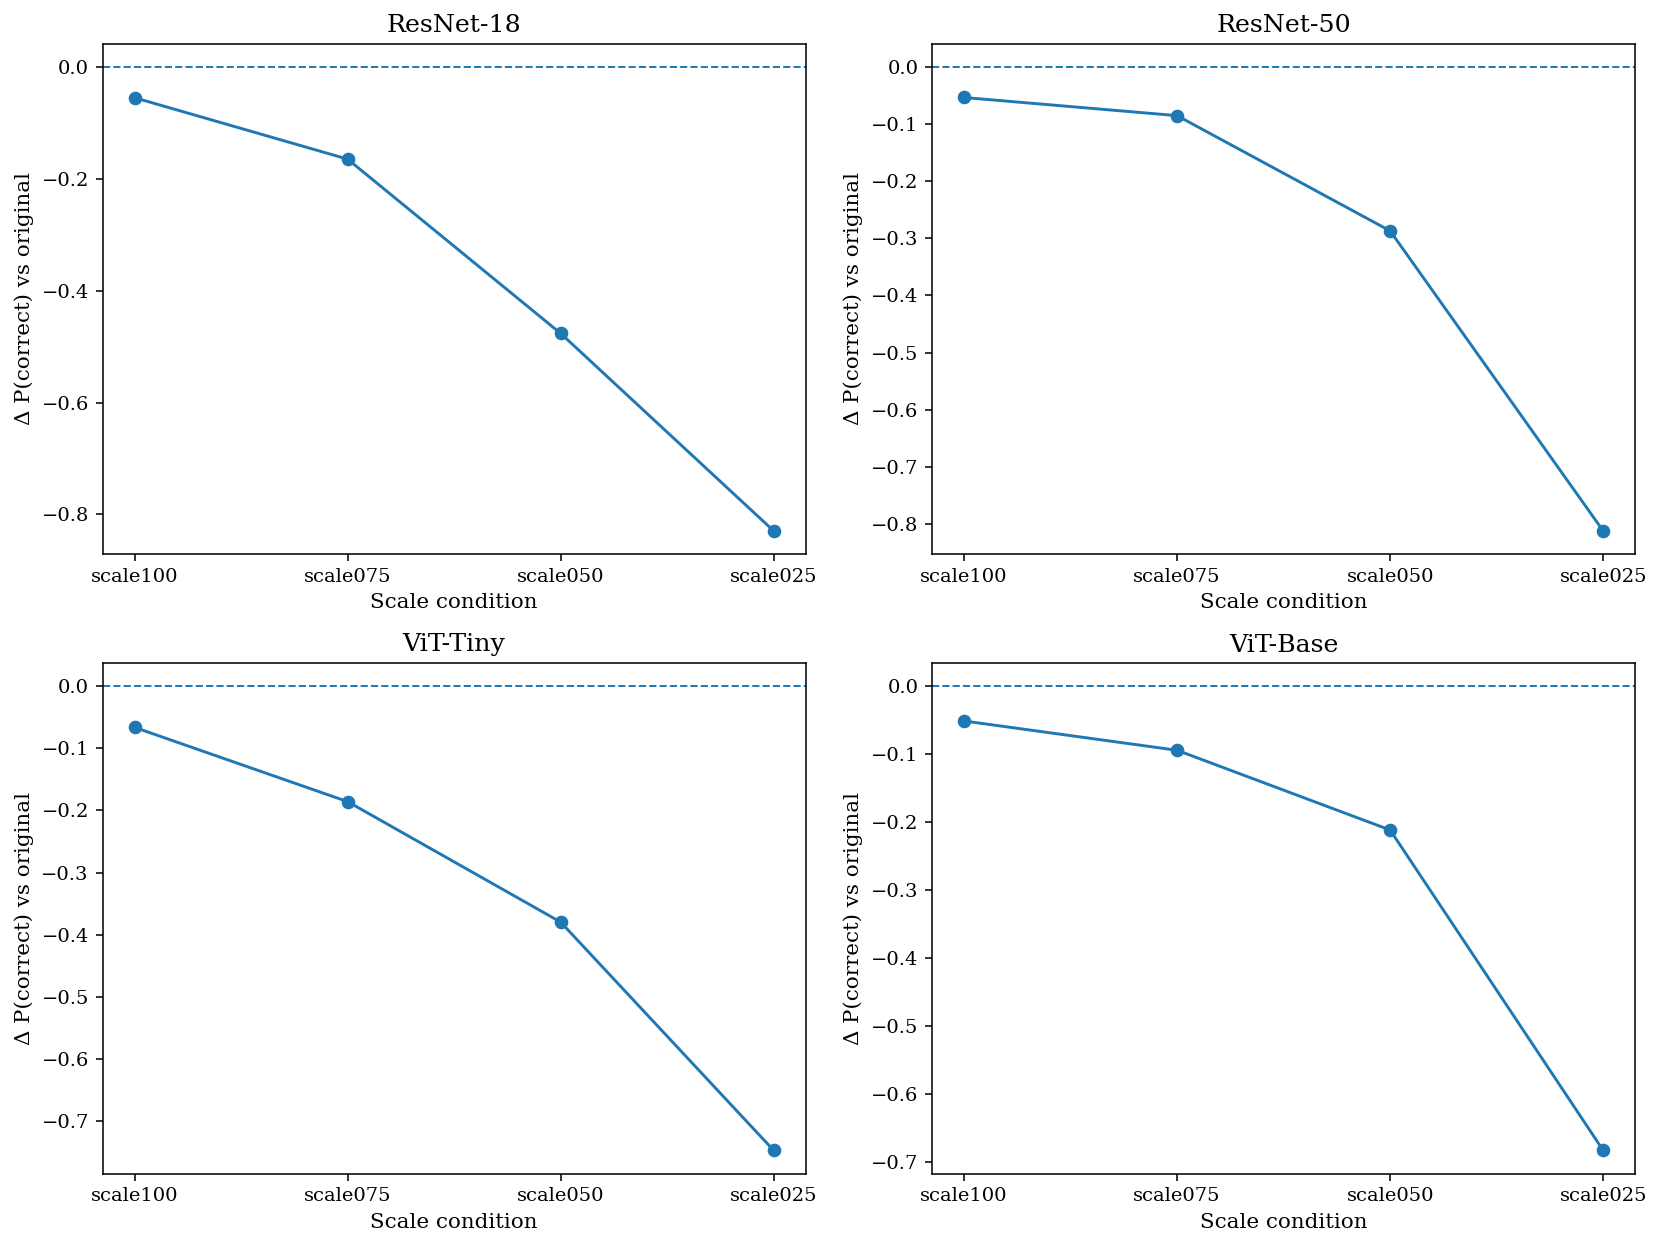

In [20]:
n_models = len(MODEL_TAGS)
ncols = 2
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, MODEL_TAGS):
    sub = overall_by_model_scale[overall_by_model_scale["model"] == model_name].copy()
    ax.plot(sub["scale_tag"].astype(str), sub["delta_prob_vs_orig"], marker="o")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Scale condition")
    ax.set_ylabel("Δ P(correct) vs original")

for ax in axes[len(MODEL_TAGS):]:
    ax.axis("off")

savefig("09_small_multiples_delta_prob_vs_original.png")

In [21]:
pivot_top1 = overall_by_model_scale.pivot(index="model", columns="scale_tag", values="top1")
pivot_top5 = overall_by_model_scale.pivot(index="model", columns="scale_tag", values="top5")
pivot_dprob = overall_by_model_scale.pivot(index="model", columns="scale_tag", values="delta_prob_vs_orig")
pivot_changed = overall_by_model_scale.pivot(index="model", columns="scale_tag", values="pred_changed_rate")

pivot_top1.insert(0, "original", [mean01(original_dfs[m]["correct_in_top1"]) for m in pivot_top1.index])
pivot_top5.insert(0, "original", [mean01(original_dfs[m]["correct_in_top5"]) for m in pivot_top5.index])
pivot_dprob.insert(0, "original", 0.0)
pivot_changed.insert(0, "original", 0.0)

pivot_top1.to_csv(ANALYSIS_DIR / "pivot_top1.csv")
pivot_top5.to_csv(ANALYSIS_DIR / "pivot_top5.csv")
pivot_dprob.to_csv(ANALYSIS_DIR / "pivot_delta_prob_vs_original.csv")
pivot_changed.to_csv(ANALYSIS_DIR / "pivot_pred_changed_rate.csv")

display(pivot_top1)
display(pivot_dprob)

scale_tag,original,scale100,scale075,scale050,scale025
model,,,,,
ResNet-18,1.0,0.890909,0.836364,0.509091,0.090909
ResNet-50,1.0,0.927273,0.927273,0.763636,0.163636
ViT-Base,1.0,0.981818,0.909091,0.836364,0.327273
ViT-Tiny,1.0,0.927273,0.818182,0.618182,0.163636


scale_tag,original,scale100,scale075,scale050,scale025
model,,,,,
ResNet-18,0.0,-0.055124,-0.164913,-0.476440,-0.829509
ResNet-50,0.0,-0.053603,-0.085375,-0.287080,-0.812214
ViT-Base,0.0,-0.050902,-0.093977,-0.211244,-0.682418
ViT-Tiny,0.0,-0.066038,-0.185694,-0.379799,-0.747702


In [22]:
summary = {
    "experiment_root": str(EXPERIMENT_ROOT),
    "analysis_dir": str(ANALYSIS_DIR),
    "models": list(MODEL_TAGS.keys()),
    "scale_order": list(map(str, SCALE_ORDER)),
    "files": {
        "overall_by_model_scale": "overall_by_model_scale.csv",
        "original_vs_pipeline_baseline": "original_vs_pipeline_baseline.csv",
        "class_by_model_scale": "class_by_model_scale.csv",
        "best_worst_classes_smallest_scale": "best_worst_classes_smallest_scale.csv",
    }
}
with open(ANALYSIS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
summary

{'experiment_root': '/data/local/rgaisina/experiments_final/inpainting_rescale_size_for_prediction',
 'analysis_dir': '/data/local/rgaisina/experiments_final/inpainting_rescale_size_for_prediction/eval_results_1',
 'models': ['ResNet-18', 'ResNet-50', 'ViT-Tiny', 'ViT-Base'],
 'scale_order': ['scale100', 'scale075', 'scale050', 'scale025'],
 'files': {'overall_by_model_scale': 'overall_by_model_scale.csv',
  'original_vs_pipeline_baseline': 'original_vs_pipeline_baseline.csv',
  'class_by_model_scale': 'class_by_model_scale.csv',
  'best_worst_classes_smallest_scale': 'best_worst_classes_smallest_scale.csv'}}